# 02 — Feature Engineering
Build lag features and save the processed dataset for all experiments.

In [6]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.preprocessing import load_data, drop_leakage_columns, fix_target, encode_booleans
from src.features import build_all_features
from src.config import PROCESSED_DIR, BASE_FEATURES, LAG_FEATURES, TARGET

## 1. Load and Clean

In [7]:
df = load_data()
df = drop_leakage_columns(df)
df = fix_target(df)
df = encode_booleans(df)
print(f'After cleaning: {df.shape}')

✅ Loaded: 47,033 rows × 76 columns
✅ Dropped 28 leakage/null columns → 48 remain
⚠️  Clipping 7 negative 'Earned Premium' values to 0
✅ Encoded 6 boolean columns to int
After cleaning: (47033, 48)


## 2. Build Lag Features

In [8]:
df = build_all_features(df)
print('\nNew lag columns added:')
for col in LAG_FEATURES:
    nulls = df[col].isnull().sum()
    print(f'  {col:<30} nulls: {nulls:,}')

✅ Feature engineering complete → 56 total columns

New lag columns added:
  premium_lag1                   nulls: 2,251
  premium_lag2                   nulls: 4,408
  premium_yoy_change             nulls: 4,408
  premium_pct_change             nulls: 4,408
  loss_ratio_lag1                nulls: 2,251
  prem_per_exp_lag1              nulls: 2,251


## 3. Why Lag-1 Is Our Strongest Feature

Correlation with Earned Premium:
premium_lag1          0.1348
prem_per_exp_lag1     0.1141
premium_yoy_change    0.0858
premium_lag2          0.0220
loss_ratio_lag1       0.0149
premium_pct_change   -0.0073
Name: Earned Premium, dtype: float64


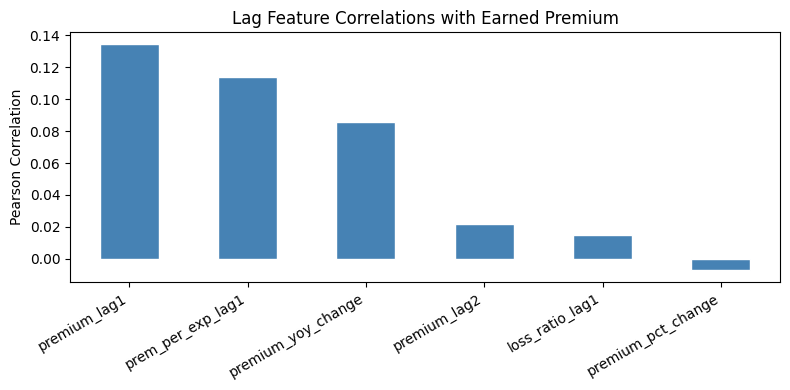

In [9]:
corr_df = df[LAG_FEATURES + [TARGET]].dropna()
correlations = corr_df.corr()[TARGET].drop(TARGET).sort_values(ascending=False)
print('Correlation with Earned Premium:')
print(correlations.round(4))

plt.figure(figsize=(8, 4))
correlations.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Lag Feature Correlations with Earned Premium')
plt.ylabel('Pearson Correlation')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../results/figures/lag_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Save Processed Dataset

In [10]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
out_path = PROCESSED_DIR / 'insurance_processed.csv'
df.to_csv(out_path, index=False)
print(f'✅ Saved processed dataset → {out_path}')
print(f'   Shape: {df.shape}')
print('\nReady for experiments A, B, C, D')

✅ Saved processed dataset → /Users/aishwaryadas/deloitte-challenge-2026/insurance-model/data/processed/insurance_processed.csv
   Shape: (47033, 56)

Ready for experiments A, B, C, D
